# 데이터 파이프라인과 관측 통계

> 2026-10-05 안내: 이 노트북의 그림·표는 오류 수정 후의 기존 실행을 다룹니다. 최신 다중 시드 결과와 현재 본문/부록 배치는 02 노트북 및 reports/baseline_benchmarks_and_future_plan.md를 참고하십시오.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from IPython.display import display, Image
ROOT = Path.cwd()
if not (ROOT/'configs/base_config.yaml').exists(): ROOT = ROOT.parent
manifest = json.loads((ROOT/'reports/corrected_run_manifest.json').read_text(encoding='utf-8'))
run = ROOT/'models/runs'/manifest['run_id']
print(manifest['run_id'], '|', manifest['test_role'])

corrected_v3_20261004T005217+0900 | development_benchmark_previously_consulted


2026년 기상은 미관측으로 남깁니다. 영발전 비율의 분모는 기간별로 구분합니다. 관측소 풍속과 발전량의 연관성은 터빈 시동 법칙 또는 인과 효과의 검증이 아닙니다.

In [2]:
display(pd.read_csv(ROOT/'reports/tables/data_quality_by_scope.csv'))
display(pd.read_csv(ROOT/'reports/tables/zero_wind_bin_analysis.csv'))

,scope,rows,valid,missing,exact_zero,zero_pct,min_positive,weather_missing_rows
0,file_all,28440,28368,72,4976,17.540891,0.024316,2198
1,study_2023_2025,26303,26303,0,4799,18.245067,0.024316,61
2,test_2025,8760,8760,0,1426,16.278539,0.024316,0


,wind_bin,total_hours,zero_hours,mean_generation_mwh,max_generation_mwh,zero_probability
0,"[0, 2)",4440,2548,0.304659,14.929895,0.573874
1,"[2, 4)",9615,2045,1.234443,17.726211,0.212689
2,"[4, 6)",6859,136,4.359269,17.385789,0.019828
3,"[6, 8)",3359,37,8.305047,19.282421,0.011015
4,"[8, 10)",1368,16,11.233290,19.987579,0.011696
5,"[10, 30)",625,5,11.770243,20.109158,0.008000


In [3]:
d = pd.read_parquet(ROOT/'data/processed/merged_dataset.parquet')
y = d.generation_mwh
print('미소 양수 (0,1e-4]:', int(((y>0)&(y<=1e-4)).sum()))
print('2026년 AWS 가용:', int(d.loc[d.datetime.dt.year==2026,'aws_wind_speed'].notna().sum()))
assert d.loc[d.datetime.dt.year==2026,'aws_wind_speed'].isna().all()

미소 양수 (0,1e-4]: 0
2026년 AWS 가용: 0


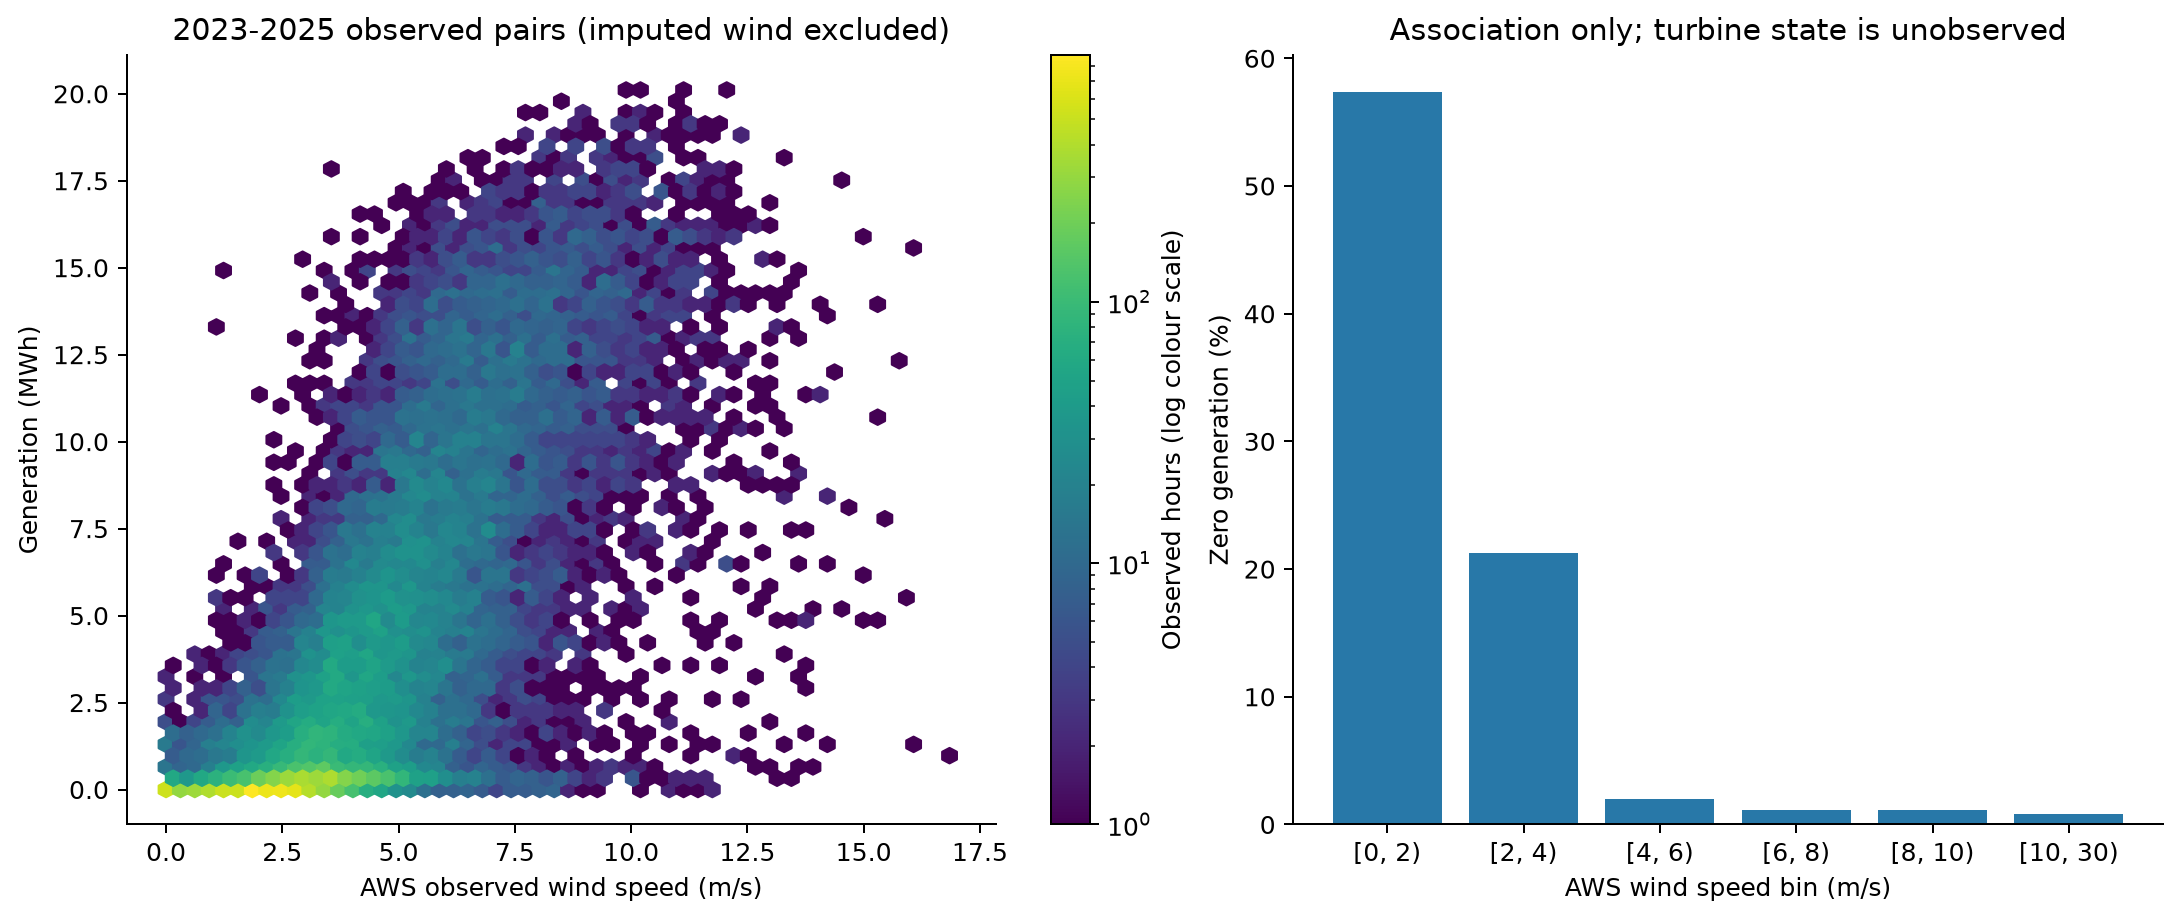

In [4]:
display(Image(filename=str(ROOT/'reports/figures/generation_eda_overview.png')))